## classification problem

In [473]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [474]:
data=pd.read_csv('breast-cancer.csv')
print(data.shape)
data.head()

(286, 10)


,target,age,menopause,tumor_size,inv_nodes,node_caps,deg_malig,breast,breast_quad,irradiat
0,no-recurrence-events,30-39,premeno,30-34,0-2,no,3,left,left_low,no
1,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,right,right_up,no
2,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,left,left_low,no
3,no-recurrence-events,60-69,ge40,15-19,0-2,no,2,right,left_up,no
4,no-recurrence-events,40-49,premeno,0-4,0-2,no,2,right,right_low,no


In [475]:
data.dtypes

target         object
age            object
menopause      object
tumor_size     object
inv_nodes      object
node_caps      object
deg_malig       int64
breast         object
breast_quad    object
irradiat       object
dtype: object

In [476]:

data.dtypes
data.head()



,target,age,menopause,tumor_size,inv_nodes,node_caps,deg_malig,breast,breast_quad,irradiat
0,no-recurrence-events,30-39,premeno,30-34,0-2,no,3,left,left_low,no
1,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,right,right_up,no
2,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,left,left_low,no
3,no-recurrence-events,60-69,ge40,15-19,0-2,no,2,right,left_up,no
4,no-recurrence-events,40-49,premeno,0-4,0-2,no,2,right,right_low,no


In [477]:
dic={}
from typing import List
for i in data.columns:
    print(data[i].nunique(),data[i].unique())
    if data[i].dtype!=int:      
        dic[i]=list(data[i].unique())
print(dic)
    

2 ['no-recurrence-events' 'recurrence-events']
6 ['30-39' '40-49' '60-69' '50-59' '70-79' '20-29']
3 ['premeno' 'ge40' 'lt40']
11 ['30-34' '20-24' '15-19' '0-4' '25-29' '50-54' 'Oct-14' '40-44' '35-39'
 '05-Sep' '45-49']
7 ['0-2' '06-Aug' '09-Nov' '03-May' '15-17' 'Dec-14' '24-26']
3 ['no' 'yes' '?']
3 [3 2 1]
2 ['left' 'right']
6 ['left_low' 'right_up' 'left_up' 'right_low' 'central' '?']
2 ['no' 'yes']
{'target': ['no-recurrence-events', 'recurrence-events'], 'age': ['30-39', '40-49', '60-69', '50-59', '70-79', '20-29'], 'menopause': ['premeno', 'ge40', 'lt40'], 'tumor_size': ['30-34', '20-24', '15-19', '0-4', '25-29', '50-54', 'Oct-14', '40-44', '35-39', '05-Sep', '45-49'], 'inv_nodes': ['0-2', '06-Aug', '09-Nov', '03-May', '15-17', 'Dec-14', '24-26'], 'node_caps': ['no', 'yes', '?'], 'deg_malig': [3, 2, 1], 'breast': ['left', 'right'], 'breast_quad': ['left_low', 'right_up', 'left_up', 'right_low', 'central', '?'], 'irradiat': ['no', 'yes']}


In [478]:
for i in data.columns:
    print(data[i].notna().sum())

286
286
286
286
286
286
286
286
286
286


In [479]:
for (key,value) in dic.items():
    data[key]=data[key].apply(lambda x:value.index(x))
data.head


<bound method NDFrame.head of      target  age  menopause  tumor_size  inv_nodes  node_caps  deg_malig  \
0         0    0          0           0          0          0          0   
1         0    1          0           1          0          0          1   
2         0    1          0           1          0          0          1   
3         0    2          1           2          0          0          1   
4         0    1          0           3          0          0          1   
..      ...  ...        ...         ...        ...        ...        ...   
281       1    0          0           0          0          0          1   
282       1    0          0           1          0          0          0   
283       1    2          1           1          0          0          2   
284       1    1          1           0          3          0          0   
285       1    3          1           0          3          0          0   

     breast  breast_quad  irradiat  
0         0         

In [480]:
# for column in data.columns:
#         plt.figure(figsize=(6, 4))  # Set figure size
#         if data[column].dtype == 'object':  # Categorical data (e.g., strings)
#             sns.countplot(data=data)
#             plt.title(f'Count plot for {column}')
#         else:  # Numeric data (e.g., integers, floats)
#             sns.histplot(y=data[column],x=data['target'] ,kde=True)  # Histogram + KDE curve
#             plt.title(f'Histogram for {column}')
    
#         plt.xlabel(column)
#         plt.ylabel('Frequency')
#         plt.show()

<Axes: >

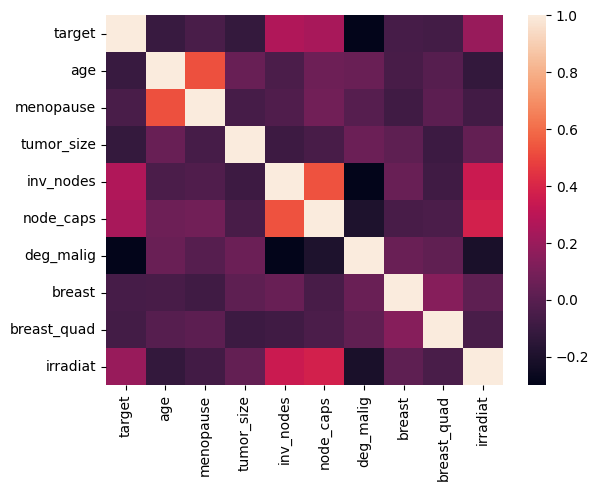

In [481]:
sns.heatmap(data.corr())

In [482]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model1=LogisticRegression()
Y=data['target']
X=data.drop('target',axis=1)

X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.1)



In [483]:
model.fit(X_train,Y_train)
Y_predict2=model.predict(X_test)



In [484]:
model1.fit(X_train,Y_train)

LogisticRegression()

In [485]:
Y_predict=model1.predict(X_test)

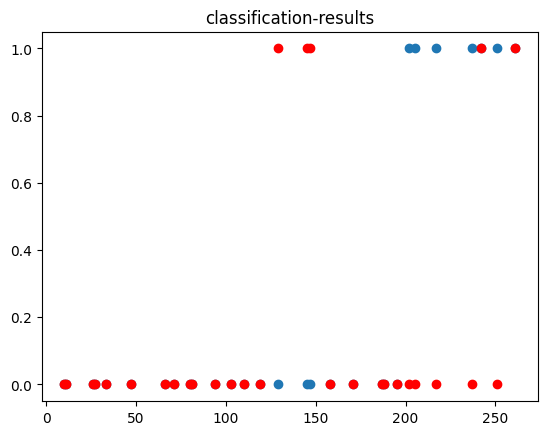

In [486]:
plt.scatter(X_test.index,Y_test)
plt.scatter(X_test.index,Y_predict2,c='red')
plt.title('classification-results')
plt.show()


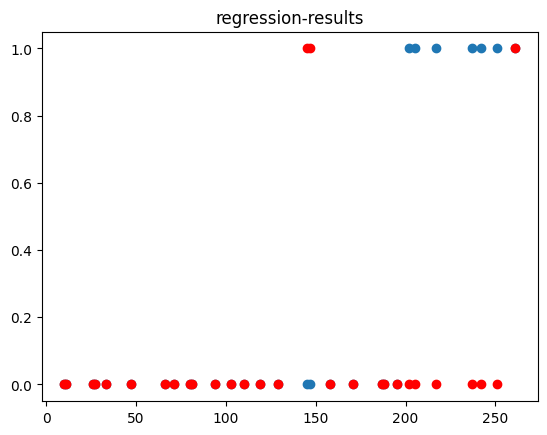

In [487]:
plt.scatter(X_test.index,Y_test)
plt.scatter(X_test.index,Y_predict,c='red')
plt.title('regression-results')
plt.show()

In [488]:
from sklearn.metrics import accuracy_score
print('logistic-regression',accuracy_score(Y_test,Y_predict))
print('guassian-nb',accuracy_score(Y_test,Y_predict2))


logistic-regression 0.7241379310344828
guassian-nb 0.7241379310344828
